In [6]:
import os
import json
import time
from math import radians, sin, cos, asin, sqrt
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from tqdm import tqdm

# ============================================================
# 0. KONFIGURASI GLOBAL (VERSI MAC)
# ============================================================

BMKG_PATH = "/Volumes/Extreme SSD/Indonesian Earthquake Catalog (BMKG), 1998–2024/BMKG_Earthquake_Catalog.csv"
USGS_PATH = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/usgs_katalog/katalog_usgs_master_2001_2025.csv"
RADAR_JSON_PATH = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/radar_inventory_3ch_detailed.json"

SAVE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid"
LOG_PATH = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/hybrid_download_log.csv"
DASHBOARD_HTML = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/hybrid_dashboard.html"

os.makedirs(SAVE_DIR, exist_ok=True)

client_iris = Client("EARTHSCOPE", timeout=30)
client_gfz = Client("GFZ", timeout=30)

TIME_TOL = pd.Timedelta("120s")
DIST_TOL_KM = 50
RADAR_MATCH_TOL = pd.Timedelta("2s")
MAX_WORKERS = 16  # multi-threaded downloader


# ============================================================
# 1. UTILITAS
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c


# ============================================================
# 2. LOAD & NORMALISASI KATALOG BMKG & USGS (FIX TZ)
# ============================================================

def load_catalogs():
    print("📥 Load katalog BMKG & USGS...")

    bmkg = pd.read_csv(BMKG_PATH)
    bmkg["origin_time"] = pd.to_datetime(
        bmkg["Date"] + " " + bmkg["Time (UTC)"],
        errors="coerce",
        utc=True
    )

    usgs = pd.read_csv(USGS_PATH)
    usgs["time"] = pd.to_datetime(
        usgs["time"],
        format="mixed",
        errors="coerce",
        utc=True
    )

    bmkg = bmkg[
        bmkg["Longitude"].between(92, 142) &
        bmkg["Latitude"].between(-11, 14)
    ].copy()

    usgs = usgs[
        usgs["longitude"].between(92, 142) &
        usgs["latitude"].between(-11, 14)
    ].copy()

    print(f"   BMKG events: {len(bmkg)}")
    print(f"   USGS events: {len(usgs)}")
    return bmkg, usgs


# ============================================================
# 3. BUILD KATALOG HYBRID BMKG ↔ USGS
# ============================================================

def build_hybrid_catalog(bmkg, usgs):
    print("🔗 Matching BMKG → USGS...")

    matches = []

    for idx, row in tqdm(bmkg.iterrows(), total=len(bmkg), desc="Matching", unit="ev"):
        t_b = row["origin_time"]
        lat_b = row["Latitude"]
        lon_b = row["Longitude"]

        cand = usgs[
            (usgs["time"] >= t_b - TIME_TOL) &
            (usgs["time"] <= t_b + TIME_TOL)
        ].copy()

        if cand.empty:
            matches.append({"bmkg_index": idx, "usgs_index": None})
            continue

        cand["dist_km"] = cand.apply(
            lambda r: haversine(lat_b, lon_b, r["latitude"], r["longitude"]),
            axis=1
        )
        cand = cand[cand["dist_km"] <= DIST_TOL_KM]

        if cand.empty:
            matches.append({"bmkg_index": idx, "usgs_index": None})
            continue

        cand["dt_abs"] = (cand["time"] - t_b).abs()
        best = cand.sort_values(["dist_km", "dt_abs"]).iloc[0]

        matches.append({
            "bmkg_index": idx,
            "usgs_index": best.name
        })

    hybrid_rows = []
    for m in matches:
        b = bmkg.loc[m["bmkg_index"]]

        if m["usgs_index"] is None:
            hybrid_rows.append({
                "source": "BMKG_ONLY",
                "bmkg_index": int(m["bmkg_index"]),
                "usgs_index": None,
                "bmkg_time": b["origin_time"],
                "bmkg_lat": b["Latitude"],
                "bmkg_lon": b["Longitude"],
                "bmkg_mag": b["Magnitude"],
                "usgs_time": None,
                "usgs_lat": None,
                "usgs_lon": None,
                "usgs_mag": None,
                "usgs_depth": None
            })
        else:
            u = usgs.loc[m["usgs_index"]]
            hybrid_rows.append({
                "source": "BMKG+USGS",
                "bmkg_index": int(m["bmkg_index"]),
                "usgs_index": int(m["usgs_index"]),
                "bmkg_time": b["origin_time"],
                "bmkg_lat": b["Latitude"],
                "bmkg_lon": b["Longitude"],
                "bmkg_mag": b["Magnitude"],
                "usgs_time": u["time"],
                "usgs_lat": u["latitude"],
                "usgs_lon": u["longitude"],
                "usgs_mag": u["mag"],
                "usgs_depth": u["depth"]
            })

    hybrid = pd.DataFrame(hybrid_rows)
    print(f"   Hybrid total: {len(hybrid)}")
    print(f"   BMKG+USGS   : {(hybrid['source']=='BMKG+USGS').sum()}")
    print(f"   BMKG_ONLY   : {(hybrid['source']=='BMKG_ONLY').sum()}")
    return hybrid


# ============================================================
# 4. LOAD RADAR JSON
# ============================================================

def load_radar_events():
    with open(RADAR_JSON_PATH, "r") as f:
        events = json.load(f)
    print(f"📡 Radar events: {len(events)}")
    return events


# ============================================================
# 5. LOOKUP HYBRID
# ============================================================

def build_hybrid_lookup(hybrid):
    return {int(row["bmkg_index"]): row for _, row in hybrid.iterrows()}


# ============================================================
# 6. STATION HEALTH CACHE (AUTO-DETECT STASIUN AKTIF)
# ============================================================

station_health_cache = {}  # sta_code -> "ACTIVE" / "NO_DATA" / "UNKNOWN"

def check_station_active(sta_code):
    if sta_code in station_health_cache:
        return station_health_cache[sta_code]

    # Cek dengan window dummy kecil di masa lalu
    try:
        t_dummy = UTCDateTime("2015-01-01T00:00:00")
        for client in (client_iris, client_gfz):
            try:
                st = client.get_waveforms(
                    network="*",
                    station=sta_code,
                    location="*",
                    channel="BH?,HH?,EH?",
                    starttime=t_dummy,
                    endtime=t_dummy + 60
                )
                if len(st) > 0:
                    station_health_cache[sta_code] = "ACTIVE"
                    return "ACTIVE"
            except:
                continue
    except:
        pass

    station_health_cache[sta_code] = "NO_DATA"
    return "NO_DATA"


# ============================================================
# 7. DOWNLOAD WAVEFORM (UNTUK SATU TASK)
# ============================================================

def download_task(task):
    """
    task: dict {
        'event': radar_event_dict,
        'hybrid_row': hybrid_row_dict,
        'station': sta_code
    }
    """
    ev = task["event"]
    hrow = task["hybrid_row"]
    sta_code = task["station"]

    if hrow["source"] != "BMKG+USGS":
        return {
            "Event_ID": ev["Event_ID"],
            "BMKG_Index": int(hrow["bmkg_index"]),
            "source": hrow["source"],
            "station": sta_code,
            "status": "SKIP_BMKG_ONLY"
        }

    if pd.isna(hrow["usgs_time"]):
        return {
            "Event_ID": ev["Event_ID"],
            "BMKG_Index": int(hrow["bmkg_index"]),
            "source": hrow["source"],
            "station": sta_code,
            "status": "SKIP_NO_USGS_TIME"
        }

    # Auto-detect station active
    health = check_station_active(sta_code)
    if health != "ACTIVE":
        return {
            "Event_ID": ev["Event_ID"],
            "BMKG_Index": int(hrow["bmkg_index"]),
            "source": hrow["source"],
            "station": sta_code,
            "status": "SKIP_STATION_INACTIVE"
        }

    event_time = UTCDateTime(hrow["usgs_time"].to_pydatetime())
    file_name = f"{sta_code}_{ev['Event_ID']}.mseed"
    file_path = os.path.join(SAVE_DIR, file_name)

    if os.path.exists(file_path):
        return {
            "Event_ID": ev["Event_ID"],
            "BMKG_Index": int(hrow["bmkg_index"]),
            "source": hrow["source"],
            "station": sta_code,
            "status": "EXIST"
        }

    t_start = event_time - 60
    t_end = event_time + 180

    for client in (client_iris, client_gfz):
        try:
            st = client.get_waveforms(
                network="*",
                station=sta_code,
                location="*",
                channel="BH?,HH?,EH?",
                starttime=t_start,
                endtime=t_end
            )
            if len(st) > 0:
                st.write(file_path, format="MSEED")
                return {
                    "Event_ID": ev["Event_ID"],
                    "BMKG_Index": int(hrow["bmkg_index"]),
                    "source": hrow["source"],
                    "station": sta_code,
                    "status": "OK"
                }
        except:
            continue

    return {
        "Event_ID": ev["Event_ID"],
        "BMKG_Index": int(hrow["bmkg_index"]),
        "source": hrow["source"],
        "station": sta_code,
        "status": "FAIL"
    }


# ============================================================
# 8. DASHBOARD HTML
# ============================================================

def build_dashboard(log_df: pd.DataFrame):
    if log_df.empty:
        html = "<html><body><h2>No data in log yet.</h2></body></html>"
        with open(DASHBOARD_HTML, "w") as f:
            f.write(html)
        return

    summary = log_df["status"].value_counts().to_frame("count")
    summary["percent"] = (summary["count"] / len(log_df) * 100).round(2)

    html = []
    html.append("<html><head><meta charset='utf-8'><title>Hybrid Download Dashboard</title>")
    html.append("<style>body{font-family:Arial, sans-serif;margin:20px;} table{border-collapse:collapse;} th,td{border:1px solid #ccc;padding:4px 8px;} th{background:#eee;} .ok{color:green;font-weight:bold;} .fail{color:red;font-weight:bold;} .skip{color:#999;} </style>")
    html.append("</head><body>")
    html.append("<h1>Hybrid Waveform Download Dashboard</h1>")

    html.append("<h2>Summary</h2>")
    html.append(summary.to_html(classes="summary", border=0))

    html.append("<h2>Sample Log (first 200 rows)</h2>")
    sample = log_df.head(200).copy()
    html.append(sample.to_html(classes="log", border=0, index=False))

    html.append("</body></html>")

    with open(DASHBOARD_HTML, "w") as f:
        f.write("\n".join(html))


# ============================================================
# 9. ORKESTRASI UTAMA (MULTI-THREADED + AUTO-SKIP)
# ============================================================

def run_hybrid_pipeline():
    bmkg, usgs = load_catalogs()
    hybrid = build_hybrid_catalog(bmkg, usgs)
    radar_events = load_radar_events()
    hybrid_lookup = build_hybrid_lookup(hybrid)

    tasks = []

    print("🧩 Menyusun task download (auto-skip event yang tidak match BMKG)...")
    for ev in tqdm(radar_events, desc="Build tasks", unit="event"):
        t_radar = pd.to_datetime(ev["Time_UTC"], utc=True)

        dt = (bmkg["origin_time"] - t_radar).abs()
        closest_idx = dt.idxmin()

        if dt.min() > RADAR_MATCH_TOL:
            # event radar tidak match BMKG → auto-skip
            continue

        bmkg_idx = int(closest_idx)
        if bmkg_idx not in hybrid_lookup:
            continue

        hrow = hybrid_lookup[bmkg_idx]

        # kalau BMKG_ONLY, kita masih boleh buat task, tapi nanti status SKIP_BMKG_ONLY
        for sta_info in ev["Stations"]:
            sta_code = sta_info["station"]
            tasks.append({
                "event": ev,
                "hybrid_row": hrow,
                "station": sta_code
            })

    print(f"   Total tasks: {len(tasks)}")

    logs = []
    print(f"🚀 Mulai unduhan multi-threaded (workers={MAX_WORKERS})...")

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(download_task, t) for t in tasks]
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading", unit="task"):
            res = fut.result()
            logs.append(res)

    log_df = pd.DataFrame(logs)
    log_df.to_csv(LOG_PATH, index=False)
    print(f"\n✅ Selesai. Log disimpan di: {LOG_PATH}")

    print("📊 Membangun dashboard HTML...")
    build_dashboard(log_df)
    print(f"✅ Dashboard: {DASHBOARD_HTML}")


# ============================================================
# 10. MAIN
# ============================================================

if __name__ == "__main__":
    run_hybrid_pipeline()


📥 Load katalog BMKG & USGS...
   BMKG events: 216716
   USGS events: 62358
🔗 Matching BMKG → USGS...


Matching: 100%|██████████| 216716/216716 [01:14<00:00, 2900.43ev/s]


   Hybrid total: 216716
   BMKG+USGS   : 23590
   BMKG_ONLY   : 193126
📡 Radar events: 13547
🧩 Menyusun task download (auto-skip event yang tidak match BMKG)...


Build tasks: 100%|██████████| 13547/13547 [00:25<00:00, 534.33event/s]


   Total tasks: 133520
🚀 Mulai unduhan multi-threaded (workers=16)...


Downloading: 100%|██████████| 133520/133520 [1:58:19<00:00, 18.81task/s]   



✅ Selesai. Log disimpan di: /Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/hybrid_download_log.csv
📊 Membangun dashboard HTML...
✅ Dashboard: /Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/hybrid_dashboard.html


Kolom: ['Event_ID', 'Time_UTC', 'Magnitude', 'Stations']
Total event: 13547

⚠️ Kolom 'Status' tidak ditemukan di JSON.

=== Distribusi Tahun ===
year
2020    3912
2021     655
2022    3014
2023    2922
2024    3044
Name: count, dtype: int64


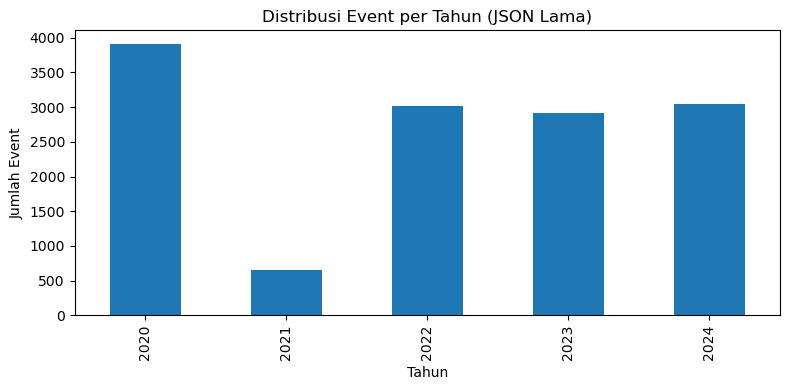

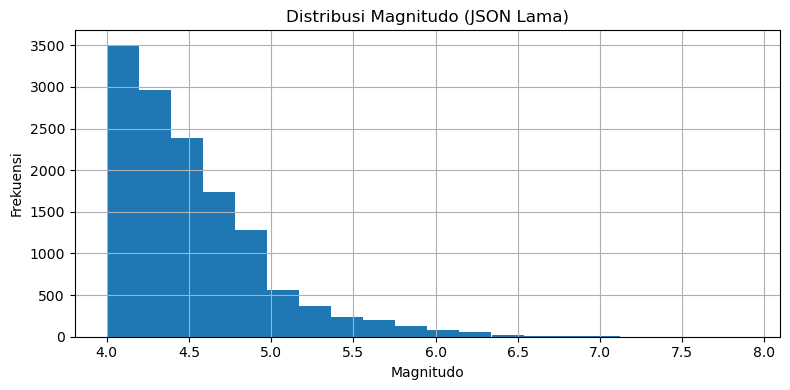


=== 15 Stasiun Paling Aktif ===
      count
BKB   13547
BOAB  13547
GSI   13547
JAGI  13547
LUWI  13547
PMBI  13547
TNTI  13547
TOLI  13547
UGM   13547
KAPI  13547


<Figure size 800x400 with 0 Axes>

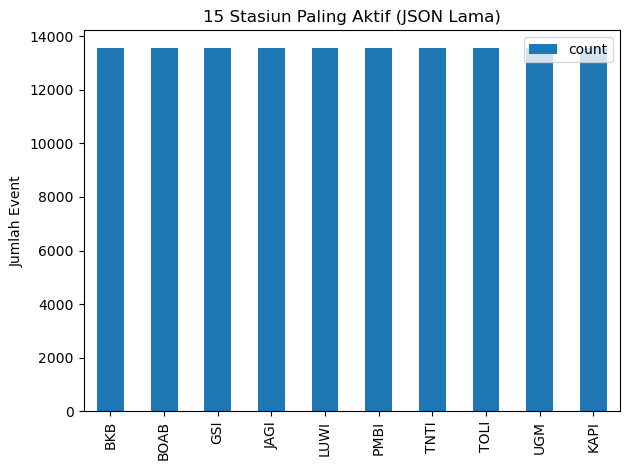

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load JSON lama
# -----------------------------
JSON_LAMA = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/radar_inventory_3ch_detailed.json"

with open(JSON_LAMA) as f:
    data_old = json.load(f)

df_old = pd.DataFrame(data_old)
print("Kolom:", df_old.columns.tolist())
print("Total event:", len(df_old))

# -----------------------------
# 2. Ringkasan status
# -----------------------------
if "Status" in df_old.columns:
    status_summary = (
        df_old["Status"]
        .value_counts()
        .to_frame("count")
    )
    status_summary["percent"] = (status_summary["count"] / len(df_old) * 100).round(2)
    print("\n=== Ringkasan Status ===")
    print(status_summary)
else:
    print("\n⚠️ Kolom 'Status' tidak ditemukan di JSON.")

# -----------------------------
# 3. Distribusi tahun
# -----------------------------
if "Time_UTC" in df_old.columns:
    df_old["year"] = pd.to_datetime(df_old["Time_UTC"]).dt.year
    year_counts = df_old["year"].value_counts().sort_index()
    print("\n=== Distribusi Tahun ===")
    print(year_counts)

    plt.figure(figsize=(8,4))
    year_counts.plot(kind="bar")
    plt.title("Distribusi Event per Tahun (JSON Lama)")
    plt.xlabel("Tahun")
    plt.ylabel("Jumlah Event")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Kolom 'Time_UTC' tidak ditemukan di JSON.")

# -----------------------------
# 4. Distribusi magnitudo
# -----------------------------
if "Magnitude" in df_old.columns:
    plt.figure(figsize=(8,4))
    df_old["Magnitude"].hist(bins=20)
    plt.title("Distribusi Magnitudo (JSON Lama)")
    plt.xlabel("Magnitudo")
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Kolom 'Magnitude' tidak ditemukan di JSON.")

# -----------------------------
# 5. Stasiun paling aktif
# -----------------------------
if "Stations" in df_old.columns:
    station_counts = {}
    for stations in df_old["Stations"]:
        if isinstance(stations, list):
            for s in stations:
                code = s.get("station")
                if code is not None:
                    station_counts[code] = station_counts.get(code, 0) + 1

    station_df = (
        pd.DataFrame.from_dict(station_counts, orient="index", columns=["count"])
        .sort_values("count", ascending=False)
    )

    print("\n=== 15 Stasiun Paling Aktif ===")
    print(station_df.head(15))

    plt.figure(figsize=(8,4))
    station_df.head(15).plot(kind="bar")
    plt.title("15 Stasiun Paling Aktif (JSON Lama)")
    plt.ylabel("Jumlah Event")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Kolom 'Stations' tidak ditemukan di JSON.")

# -----------------------------
# 6. Detail per status (jika ada)
# -----------------------------
if "Status" in df_old.columns and "year" in df_old.columns:
    print("\n=== Distribusi Status per Tahun ===")
    ctab = pd.crosstab(df_old["year"], df_old["Status"])
    print(ctab)

    plt.figure(figsize=(10,5))
    ctab.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title("Status per Tahun (JSON Lama)")
    plt.xlabel("Tahun")
    plt.ylabel("Jumlah Event")
    plt.tight_layout()
    plt.show()


In [12]:
import os
from obspy import read
import matplotlib.pyplot as plt

SAVE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid"

# ---------------------------------------------------------
# 1. Ambil semua file MSEED (abaikan file ._ dari macOS)
# ---------------------------------------------------------
files = [f for f in os.listdir(SAVE_DIR) 
         if f.endswith(".mseed") and not f.startswith("._")]

if len(files) == 0:
    raise ValueError("Tidak ada file .mseed di SAVE_DIR.")

print(f"Total file MSEED ditemukan: {len(files)}")

# ---------------------------------------------------------
# 2. Pilih event pertama berdasarkan timestamp di nama file
#    Format: STATION_BMKG-YYYYMMDDHHMMSS-001.mseed
# ---------------------------------------------------------
sample = files[0]
print(f"\n📌 Contoh file: {sample}")

# Ekstrak timestamp event
parts = sample.split("-")
timestamp = parts[1]  # YYYYMMDDHHMMSS
print(f"📌 Timestamp event: {timestamp}")

# Cari semua file yang punya timestamp sama
event_files = [f for f in files if timestamp in f]

print(f"📌 Total file untuk event ini: {len(event_files)}")
print(event_files)

# ---------------------------------------------------------
# 3. Temukan channel Z, N, E
# ---------------------------------------------------------
def find_channel(ch):
    for f in event_files:
        if ch in f:
            return os.path.join(SAVE_DIR, f)
    return None

file_Z = find_channel("Z")
file_N = find_channel("N")
file_E = find_channel("E")

print("\nBHZ:", file_Z)
print("BHN:", file_N)
print("BHE:", file_E)

if not all([file_Z, file_N, file_E]):
    raise ValueError("Tidak lengkap: BHZ/BHN/BHE tidak ditemukan untuk event ini.")

# ---------------------------------------------------------
# 4. Load waveform
# ---------------------------------------------------------
trZ = read(file_Z)[0]
trN = read(file_N)[0]
trE = read(file_E)[0]

# ---------------------------------------------------------
# 5. Plot waveform N/Z/E
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(trZ.times(), trZ.data, label="Z", color="blue")
plt.plot(trN.times(), trN.data, label="N", color="green")
plt.plot(trE.times(), trE.data, label="E", color="red")
plt.title(f"Waveform N/Z/E — Event {timestamp}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 6. Plot amplitudo maksimum per channel
# ---------------------------------------------------------
amp_Z = abs(trZ.data).max()
amp_N = abs(trN.data).max()
amp_E = abs(trE.data).max()

plt.figure(figsize=(6,4))
plt.bar(["Z", "N", "E"], [amp_Z, amp_N, amp_E], color=["blue", "green", "red"])
plt.title(f"Peak Amplitude per Channel — Event {timestamp}")
plt.ylabel("Amplitude")
plt.grid(axis="y")
plt.show()

print("\nPeak amplitudes:")
print("Z:", amp_Z)
print("N:", amp_N)
print("E:", amp_E)


Total file MSEED ditemukan: 23490

📌 Contoh file: BKB_BMKG-20200101043805-001.mseed
📌 Timestamp event: 20200101043805
📌 Total file untuk event ini: 9
['BKB_BMKG-20200101043805-001.mseed', 'BOAB_BMKG-20200101043805-001.mseed', 'GSI_BMKG-20200101043805-001.mseed', 'JAGI_BMKG-20200101043805-001.mseed', 'LUWI_BMKG-20200101043805-001.mseed', 'PMBI_BMKG-20200101043805-001.mseed', 'TNTI_BMKG-20200101043805-001.mseed', 'UGM_BMKG-20200101043805-001.mseed', 'KAPI_BMKG-20200101043805-001.mseed']

BHZ: None
BHN: /Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid/TNTI_BMKG-20200101043805-001.mseed
BHE: None


ValueError: Tidak lengkap: BHZ/BHN/BHE tidak ditemukan untuk event ini.

In [11]:
import os

SAVE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid"

print("Isi SAVE_DIR:")
print(os.listdir(SAVE_DIR))


Isi SAVE_DIR:
['BKB_BMKG-20200101043805-001.mseed', '._BKB_BMKG-20200101043805-001.mseed', 'BOAB_BMKG-20200101043805-001.mseed', '._BOAB_BMKG-20200101043805-001.mseed', 'GSI_BMKG-20200101043805-001.mseed', '._GSI_BMKG-20200101043805-001.mseed', 'JAGI_BMKG-20200101043805-001.mseed', '._JAGI_BMKG-20200101043805-001.mseed', 'LUWI_BMKG-20200101043805-001.mseed', '._LUWI_BMKG-20200101043805-001.mseed', 'PMBI_BMKG-20200101043805-001.mseed', '._PMBI_BMKG-20200101043805-001.mseed', 'TNTI_BMKG-20200101043805-001.mseed', '._TNTI_BMKG-20200101043805-001.mseed', 'UGM_BMKG-20200101043805-001.mseed', '._UGM_BMKG-20200101043805-001.mseed', 'KAPI_BMKG-20200101043805-001.mseed', '._KAPI_BMKG-20200101043805-001.mseed', 'BKB_BMKG-20200101060114-001.mseed', '._BKB_BMKG-20200101060114-001.mseed', 'BOAB_BMKG-20200101060114-001.mseed', '._BOAB_BMKG-20200101060114-001.mseed', 'GSI_BMKG-20200101060114-001.mseed', '._GSI_BMKG-20200101060114-001.mseed', 'JAGI_BMKG-20200101060114-001.mseed', '._JAGI_BMKG-20200101

In [13]:
import os
from obspy import read
import matplotlib.pyplot as plt

SAVE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid"

# ---------------------------------------------------------
# 1. Ambil semua file MSEED (abaikan file ._ dari macOS)
# ---------------------------------------------------------
files = [f for f in os.listdir(SAVE_DIR) 
         if f.endswith(".mseed") and not f.startswith("._")]

if len(files) == 0:
    raise ValueError("Tidak ada file .mseed di SAVE_DIR.")

print(f"Total file MSEED ditemukan: {len(files)}")

# ---------------------------------------------------------
# 2. Pilih event pertama berdasarkan timestamp di nama file
#    Format: STATION_BMKG-YYYYMMDDHHMMSS-001.mseed
# ---------------------------------------------------------
sample = files[0]
print(f"\n📌 Contoh file: {sample}")

# Ekstrak timestamp event
parts = sample.split("-")
timestamp = parts[1]  # YYYYMMDDHHMMSS
print(f"📌 Timestamp event: {timestamp}")

# Cari semua file yang punya timestamp sama
event_files = [f for f in files if timestamp in f]

print(f"📌 Total file untuk event ini: {len(event_files)}")
print(event_files)

# ---------------------------------------------------------
# 3. Temukan channel Z, N, E
# ---------------------------------------------------------
def find_channel(ch):
    for f in event_files:
        if ch in f:
            return os.path.join(SAVE_DIR, f)
    return None

file_Z = find_channel("Z")
file_N = find_channel("N")
file_E = find_channel("E")

print("\nBHZ:", file_Z)
print("BHN:", file_N)
print("BHE:", file_E)

if not all([file_Z, file_N, file_E]):
    raise ValueError("Tidak lengkap: BHZ/BHN/BHE tidak ditemukan untuk event ini.")

# ---------------------------------------------------------
# 4. Load waveform
# ---------------------------------------------------------
trZ = read(file_Z)[0]
trN = read(file_N)[0]
trE = read(file_E)[0]

# ---------------------------------------------------------
# 5. Plot waveform N/Z/E
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(trZ.times(), trZ.data, label="Z", color="blue")
plt.plot(trN.times(), trN.data, label="N", color="green")
plt.plot(trE.times(), trE.data, label="E", color="red")
plt.title(f"Waveform N/Z/E — Event {timestamp}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 6. Plot amplitudo maksimum per channel
# ---------------------------------------------------------
amp_Z = abs(trZ.data).max()
amp_N = abs(trN.data).max()
amp_E = abs(trE.data).max()

plt.figure(figsize=(6,4))
plt.bar(["Z", "N", "E"], [amp_Z, amp_N, amp_E], color=["blue", "green", "red"])
plt.title(f"Peak Amplitude per Channel — Event {timestamp}")
plt.ylabel("Amplitude")
plt.grid(axis="y")
plt.show()

print("\nPeak amplitudes:")
print("Z:", amp_Z)
print("N:", amp_N)
print("E:", amp_E)


Total file MSEED ditemukan: 23490

📌 Contoh file: BKB_BMKG-20200101043805-001.mseed
📌 Timestamp event: 20200101043805
📌 Total file untuk event ini: 9
['BKB_BMKG-20200101043805-001.mseed', 'BOAB_BMKG-20200101043805-001.mseed', 'GSI_BMKG-20200101043805-001.mseed', 'JAGI_BMKG-20200101043805-001.mseed', 'LUWI_BMKG-20200101043805-001.mseed', 'PMBI_BMKG-20200101043805-001.mseed', 'TNTI_BMKG-20200101043805-001.mseed', 'UGM_BMKG-20200101043805-001.mseed', 'KAPI_BMKG-20200101043805-001.mseed']

BHZ: None
BHN: /Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid/TNTI_BMKG-20200101043805-001.mseed
BHE: None


ValueError: Tidak lengkap: BHZ/BHN/BHE tidak ditemukan untuk event ini.

In [14]:
import os
from obspy import read
import matplotlib.pyplot as plt

SAVE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid"

# ---------------------------------------------------------
# 1. Ambil semua file MSEED (abaikan file ._ dari macOS)
# ---------------------------------------------------------
files = [f for f in os.listdir(SAVE_DIR) 
         if f.endswith(".mseed") and not f.startswith("._")]

if len(files) == 0:
    raise ValueError("Tidak ada file .mseed di SAVE_DIR.")

print(f"Total file MSEED ditemukan: {len(files)}")

# ---------------------------------------------------------
# 2. Ambil event pertama berdasarkan timestamp di nama file
#    Format: STATION_BMKG-YYYYMMDDHHMMSS-001.mseed
# ---------------------------------------------------------
sample = files[0]
parts = sample.split("-")
timestamp = parts[1]  # YYYYMMDDHHMMSS

print(f"\n📌 Event timestamp: {timestamp}")

# Cari semua file untuk event ini
event_files = [f for f in files if timestamp in f]
print(f"📌 Total file event ini: {len(event_files)}")
print(event_files)

# ---------------------------------------------------------
# 3. Baca semua file event dan kelompokkan berdasarkan channel
# ---------------------------------------------------------
channels = {}  # Z, N, E

for f in event_files:
    path = os.path.join(SAVE_DIR, f)
    st = read(path)
    tr = st[0]
    ch = tr.stats.channel[-1]  # ambil huruf terakhir: Z/N/E

    if ch in ["Z", "N", "E"]:
        channels[ch] = tr

print("\nChannel ditemukan:", list(channels.keys()))

if not all(k in channels for k in ["Z", "N", "E"]):
    raise ValueError("Event ini TIDAK lengkap 3 komponen (Z, N, E).")

trZ = channels["Z"]
trN = channels["N"]
trE = channels["E"]

# ---------------------------------------------------------
# 4. Plot waveform N/Z/E
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))


Total file MSEED ditemukan: 23490

📌 Event timestamp: 20200101043805
📌 Total file event ini: 9
['BKB_BMKG-20200101043805-001.mseed', 'BOAB_BMKG-20200101043805-001.mseed', 'GSI_BMKG-20200101043805-001.mseed', 'JAGI_BMKG-20200101043805-001.mseed', 'LUWI_BMKG-20200101043805-001.mseed', 'PMBI_BMKG-20200101043805-001.mseed', 'TNTI_BMKG-20200101043805-001.mseed', 'UGM_BMKG-20200101043805-001.mseed', 'KAPI_BMKG-20200101043805-001.mseed']

Channel ditemukan: ['Z', 'E']


ValueError: Event ini TIDAK lengkap 3 komponen (Z, N, E).

In [15]:
import os
from obspy import read
import matplotlib.pyplot as plt
from collections import defaultdict

SAVE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/output/waveforms_hybrid"

# ---------------------------------------------------------
# 1. Ambil semua file MSEED (abaikan file ._)
# ---------------------------------------------------------
files = [f for f in os.listdir(SAVE_DIR) 
         if f.endswith(".mseed") and not f.startswith("._")]

print("Total file:", len(files))

# ---------------------------------------------------------
# 2. Kelompokkan file berdasarkan timestamp event
#    Format: STATION_BMKG-YYYYMMDDHHMMSS-001.mseed
# ---------------------------------------------------------
events = defaultdict(list)

for f in files:
    parts = f.split("-")
    if len(parts) < 2:
        continue
    timestamp = parts[1]  # YYYYMMDDHHMMSS
    events[timestamp].append(f)

print("Total event unik:", len(events))

# ---------------------------------------------------------
# 3. Cari event yang punya channel Z, N, E
# ---------------------------------------------------------
def detect_channels(file_list):
    ch = set()
    for f in file_list:
        st = read(os.path.join(SAVE_DIR, f))
        tr = st[0]
        ch.add(tr.stats.channel[-1])  # ambil huruf terakhir
    return ch

three_comp_events = []

for ts, flist in events.items():
    ch = detect_channels(flist)
    if {"Z", "N", "E"}.issubset(ch):
        three_comp_events.append((ts, flist))

print("\nEvent dengan 3 komponen:", len(three_comp_events))

if len(three_comp_events) == 0:
    raise ValueError("Tidak ada event yang lengkap 3 komponen di folder ini.")

# ---------------------------------------------------------
# 4. Ambil event 3C pertama
# ---------------------------------------------------------
timestamp


Total file: 23490
Total event unik: 6496

Event dengan 3 komponen: 0


ValueError: Tidak ada event yang lengkap 3 komponen di folder ini.

In [16]:
import os
from obspy import read
import matplotlib.pyplot as plt
from collections import defaultdict

SAMPLE_DIR = "/Volumes/Extreme SSD/benchmark_bmkg_indonesia/sample"

# ---------------------------------------------------------
# 1. Ambil semua file MSEED (abaikan file ._)
# ---------------------------------------------------------
files = [f for f in os.listdir(SAMPLE_DIR) 
         if f.endswith(".mseed") and not f.startswith("._")]

print("Total file:", len(files))

if len(files) == 0:
    raise ValueError("Tidak ada file .mseed di folder sample.")

# ---------------------------------------------------------
# 2. Kelompokkan file berdasarkan timestamp event
#    Format umum: STATION-YYYYMMDDHHMMSS-xxx.mseed
# ---------------------------------------------------------
events = defaultdict(list)

for f in files:
    parts = f.split("-")
    if len(parts) < 2:
        continue
    timestamp = parts[1]  # YYYYMMDDHHMMSS
    events[timestamp].append(f)

print("Total event unik:", len(events))

# ---------------------------------------------------------
# 3. Cari event yang punya channel Z, N, E
# ---------------------------------------------------------
def detect_channels(file_list):
    ch = set()
    for f in file_list:
        st = read(os.path.join(SAMPLE_DIR, f))
        tr = st[0]
        ch.add(tr.stats.channel[-1])  # ambil huruf terakhir
    return ch

three_comp_events = []

for ts, flist in events.items():
    ch = detect_channels(flist)
    if {"Z", "N", "E"}.issubset(ch):
        three_comp_events.append((ts, flist))

print("\nEvent dengan 3 komponen:", len(three_comp_events))

if len(three_comp_events) == 0:
    raise ValueError("Tidak ada event 3 komponen (Z, N, E) di folder sample.")

# ---------------------------------------------------------
# 4. Ambil event 3C pertama
# ---------------------------------------------------------
timestamp, file_list = three_comp_events[0]
print("\n📌 Menggunakan event:", timestamp)
print("File:", file_list)

# ---------------------------------------------------------
# 5. Load channel Z, N, E
# ---------------------------------------------------------
channels = {}

for f in file_list:
    st = read(os.path.join(SAMPLE_DIR, f))
    tr = st[0]
    ch = tr.stats.channel[-1]
    if ch in ["Z", "N", "E"]:
        channels[ch] = tr

trZ = channels["Z"]
trN = channels["N"]
trE = channels["E"]

# ---------------------------------------------------------
# 6. Plot waveform
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(trZ.times(), trZ.data, label="Z", color="blue")
plt.plot(trN.times(), trN.data, label="N", color="green")
plt.plot(trE.times(), trE.data, label="E", color="red")
plt.title(f"Waveform N/Z/E — Event {timestamp}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 7. Plot amplitudo maksimum
# ---------------------------------------------------------
amp_Z = abs(trZ.data).max()
amp_N = abs(trN.data).max()
amp_E = abs(trE.data).max()

plt.figure(figsize=(6,4))
plt.bar(["Z", "N", "E"], [amp_Z, amp_N, amp_E], color=["blue", "green", "red"])
plt.title(f"Peak Amplitude per Channel — Event {timestamp}")
plt.ylabel("Amplitude")
plt.grid(axis="y")
plt.show()

print("\nPeak amplitudes:")
print("Z:", amp_Z)
print("N:", amp_N)
print("E:", amp_E)


Total file: 10
Total event unik: 10

Event dengan 3 komponen: 0


ValueError: Tidak ada event 3 komponen (Z, N, E) di folder sample.